In [2]:
!pip install nltk textblob wordcloud seaborn beautifulsoup4 requests

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.9 MB/s  0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 7.6 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [click]
   ------------- -------------------------- 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\ANSH
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\ANSH
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...


True

In [6]:
import requests
from bs4 import BeautifulSoup

# Data Collection

Customer reviews were collected from the FlowerAura website using web scraping techniques. The extracted information includes customer names, ratings, and review text from multiple review pages.

In [7]:
Names = []
Ratings = []
Reviews = []

for page in range(1,51):

    url = f"https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page={page}"

    r = requests.get(url)

    soup = BeautifulSoup(r.text,"html.parser")

    sub = soup.find_all(
        "div",
        {"class":"new-review-card-container"}
    )

    for review_card in sub:

        name = review_card.find(
            "span",
            {"class":"review-author-name"}
        )

        Names.append(name.text)

        ratings_container = review_card.find(
            "span",
            {"class":"star-count-container"}
        )

        rating = ratings_container.find_all("span")[-1]

        Ratings.append(rating.text)

        review = review_card.find_all("div")[-1]

        Reviews.append(review.text.strip())

    print(url)

https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=1
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=2
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=3
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=4
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=5
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=6
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=7
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=8
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=9
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=10
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=11
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=12
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=13
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=14
https://www.flo

# Creating Dataset

The scraped data is converted into a structured Pandas DataFrame for further analysis.

In [8]:
df = pd.DataFrame({
    "Customer Name": Names,
    "Customer Ratings": Ratings,
    "Customer Reviews": Reviews
})

df.head()

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,Great experience with FlowerAura.Delivery was ...
1,Anki M,5,Fresh flowers...liked it.
2,suraj chaunal,5,the flowers were fresh and colorful. TBH they ...
3,Bakiyalakshmi,5,"Very fresh flowers, delivered on time with bea..."
4,pulak.pal77,5,Roses quality is very nice.


In [9]:
print("Total Reviews:", len(df))

df.shape

Total Reviews: 500


(500, 3)

In [10]:
df.to_csv(
    "flower_aura.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [11]:
df = pd.read_csv("flower_aura.csv")

df.head()

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,Great experience with FlowerAura.Delivery was ...
1,Anki M,5,Fresh flowers...liked it.
2,suraj chaunal,5,the flowers were fresh and colorful. TBH they ...
3,Bakiyalakshmi,5,"Very fresh flowers, delivered on time with bea..."
4,pulak.pal77,5,Roses quality is very nice.


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer Name     500 non-null    str  
 1   Customer Ratings  500 non-null    int64
 2   Customer Reviews  483 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.8 KB


# Data Cleaning and Preprocessing

The collected dataset is examined for missing values and duplicate records. Text preprocessing techniques are applied to improve the quality of review data.

In [13]:
df.isnull().sum()

Customer Name        0
Customer Ratings     0
Customer Reviews    17
dtype: int64

In [14]:
print("Duplicate Reviews:", df.duplicated().sum())

df = df.drop_duplicates()

df.shape

Duplicate Reviews: 0


(500, 3)

In [15]:
df = df.dropna()

df.isnull().sum()

Customer Name       0
Customer Ratings    0
Customer Reviews    0
dtype: int64

In [16]:
df["Customer Reviews"] = df["Customer Reviews"].str.lower()

df.head()

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,great experience with floweraura.delivery was ...
1,Anki M,5,fresh flowers...liked it.
2,suraj chaunal,5,the flowers were fresh and colorful. tbh they ...
3,Bakiyalakshmi,5,"very fresh flowers, delivered on time with bea..."
4,pulak.pal77,5,roses quality is very nice.


In [17]:
df["Customer Reviews"] = df["Customer Reviews"].apply(
    lambda x: re.sub(
        r'[^a-zA-Z\s]',
        '',
        str(x)
    )
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...
1,Anki M,5,fresh flowersliked it
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...
4,pulak.pal77,5,roses quality is very nice


In [18]:
df["Customer Reviews"] = df["Customer Reviews"].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

df.head()

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...
1,Anki M,5,fresh flowersliked it
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...
4,pulak.pal77,5,roses quality is very nice


In [19]:
stop_words = set(stopwords.words('english'))

df["Cleaned_Review"] = df["Customer Reviews"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...
1,Anki M,5,fresh flowersliked it,fresh flowersliked
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flowers fresh colorful tbh better expected thanks
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flowers delivered time beautiful packagi...
4,pulak.pal77,5,roses quality is very nice,roses quality nice


In [20]:
lemmatizer = WordNetLemmatizer()

df["Cleaned_Review"] = df["Cleaned_Review"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...
1,Anki M,5,fresh flowersliked it,fresh flowersliked
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...
4,pulak.pal77,5,roses quality is very nice,rose quality nice


# Sentiment Analysis

TextBlob is used to calculate sentiment polarity and subjectivity scores for each review. Reviews are then classified as Positive or Negative based on polarity values.

In [21]:
df["Polarity"] = df["Cleaned_Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000


## Rating vs Sentiment Analysis

This section examines the relationship between customer ratings and sentiment polarity scores.

In [22]:
df["Subjectivity"] = df["Cleaned_Review"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity,Subjectivity
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381,0.507143
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000,0.500000
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000,0.400000
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381,0.690476
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000,0.975000


In [23]:
def sentiment_label(score):

    if score >= 0.1:
        return "Positive"

    else:
        return "Negative"

df["Sentiment"] = df["Polarity"].apply(
    sentiment_label
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity,Subjectivity,Sentiment
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381,0.507143,Positive
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000,0.500000,Positive
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000,0.400000,Positive
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381,0.690476,Positive
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000,0.975000,Positive


In [24]:
df["Sentiment"].value_counts()

Sentiment
Positive    419
Negative     64
Name: count, dtype: int64

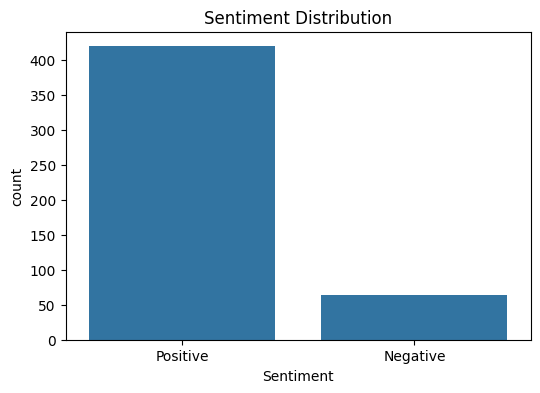

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

In [26]:
df["Customer Ratings"] = pd.to_numeric(
    df["Customer Ratings"]
)

df.info()

<class 'pandas.DataFrame'>
Index: 483 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Name     483 non-null    str    
 1   Customer Ratings  483 non-null    int64  
 2   Customer Reviews  483 non-null    str    
 3   Cleaned_Review    483 non-null    str    
 4   Polarity          483 non-null    float64
 5   Subjectivity      483 non-null    float64
 6   Sentiment         483 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 30.2 KB


In [27]:
df.groupby(
    "Customer Ratings"
)["Polarity"].mean()

Customer Ratings
1    0.700000
2    0.000000
3    0.666667
4    0.544231
5    0.530029
Name: Polarity, dtype: float64

In [28]:
correlation = df["Customer Ratings"].corr(
    df["Polarity"]
)

print("Correlation =", correlation)

Correlation = -0.007221074359845134


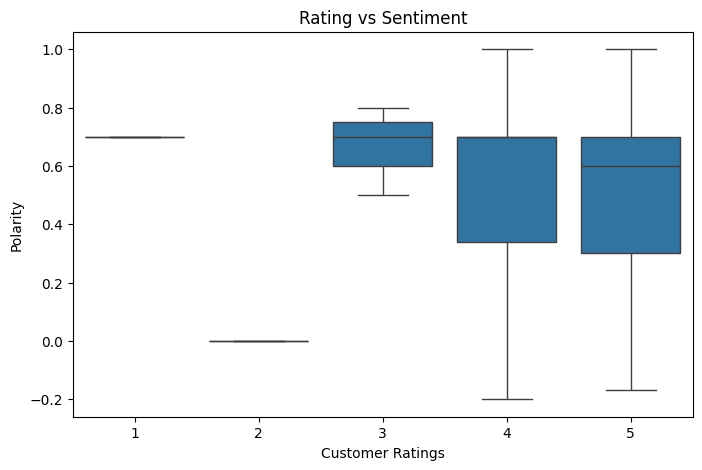

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Customer Ratings",
    y="Polarity",
    data=df
)

plt.title("Rating vs Sentiment")

plt.show()

## Word Cloud Analysis

Word clouds are generated to identify the most frequently occurring words in positive and negative reviews.

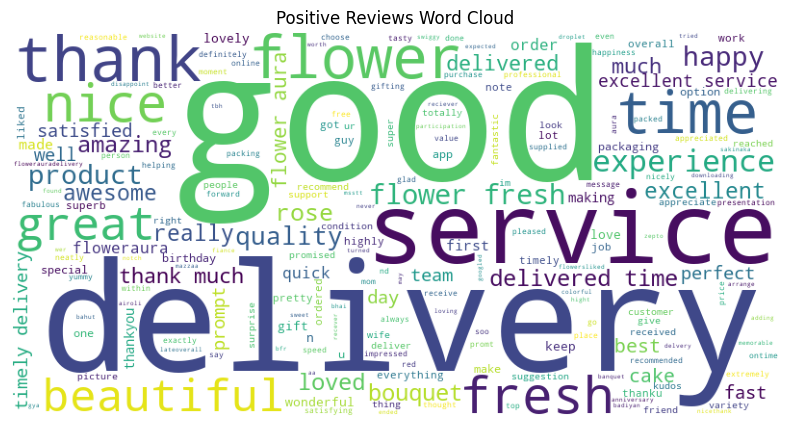

In [30]:
positive_reviews = " ".join(
    df[
        df["Sentiment"]=="Positive"
    ]["Cleaned_Review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews Word Cloud")

plt.show()

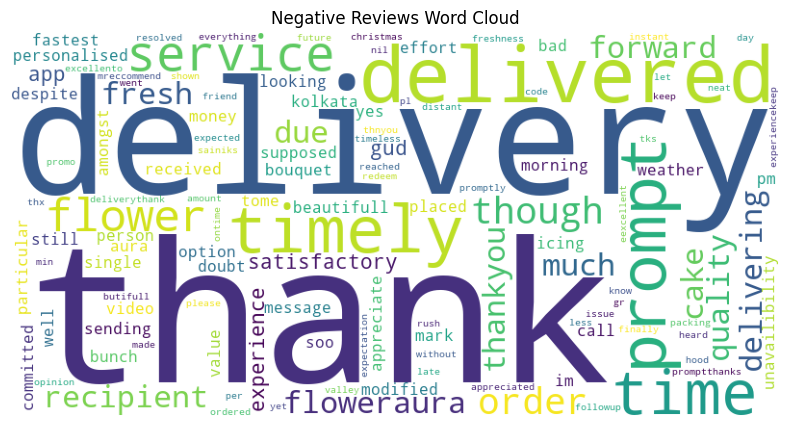

In [31]:
negative_reviews = " ".join(
    df[
        df["Sentiment"]=="Negative"
    ]["Cleaned_Review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews Word Cloud")

plt.show()

## Review Length Analysis

The relationship between review length and customer sentiment is explored.

In [32]:
df["Review_Length"] = df["Cleaned_Review"].apply(
    lambda x: len(x.split())
)

df.head()

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity,Subjectivity,Sentiment,Review_Length
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381,0.507143,Positive,10
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000,0.500000,Positive,2
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000,0.400000,Positive,7
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381,0.690476,Positive,11
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000,0.975000,Positive,3


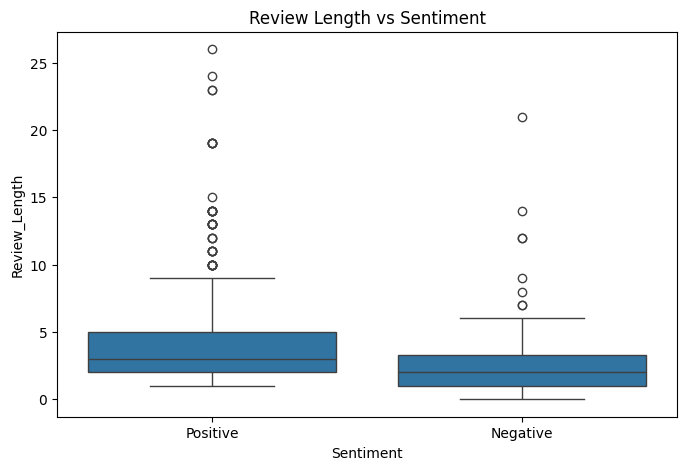

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Sentiment",
    y="Review_Length",
    data=df
)

plt.title("Review Length vs Sentiment")

plt.show()

# Sample Input and Output

The following example demonstrates how the sentiment analysis system classifies a customer review based on its polarity score.

In [34]:
sample_review = "The flowers were fresh and delivery was excellent."

polarity = TextBlob(
    sample_review
).sentiment.polarity

if polarity >= 0.1:
    sentiment = "Positive"
else:
    sentiment = "Negative"

print("Review:", sample_review)
print("Polarity:", polarity)
print("Sentiment:", sentiment)

Review: The flowers were fresh and delivery was excellent.
Polarity: 0.65
Sentiment: Positive


In [35]:
df.to_csv(
    "flower_aura_sentiment_analysis.csv",
    index=False
)

print("Final Dataset Saved")

Final Dataset Saved


**The dataset was collected from the FlowerAura website using web scraping techniques with Requests and BeautifulSoup. Customer names, ratings, and review texts were extracted from multiple review pages and stored for analysis.**

**The data was cleaned by checking for missing values, removing unnecessary characters, and preprocessing the review text through lowercasing, stop-word removal, and lemmatization. Sentiment analysis was then performed using TextBlob to classify reviews as positive or negative based on polarity scores.**

**The results showed that most customer reviews were positive, indicating a high level of customer satisfaction. Various visualizations, including sentiment distribution, rating analysis, and word clouds, were used to identify key patterns and trends in customer feedback.**

**Overall, the project successfully demonstrated web scraping, text preprocessing, sentiment analysis, and data visualization techniques to gain insights into customer opinions and experiences.**